In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from utils import get_model
EPOCHS = 10
IMG_WIDTH=30
IMG_HEIGHT=30

Study the effect of batch normalization

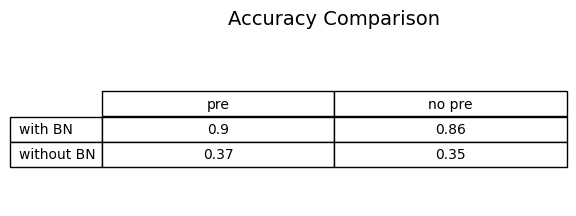

In [ ]:
# load the train and test data
train, val = np.load("train.npz"), np.load("val.npz")
X_train, y_train, X_val, y_val = train["X"], train["y"], val["X"], val["y"]
data_pres, batch_nors=[True,False], [True,False]

# one hot encoding
y_train = tf.keras.utils.to_categorical(y_train)
y_val = tf.keras.utils.to_categorical(y_val)

dropout_rate=0.6
regularizer_strength=0.01
accuracies=[[0,0],[0,0]]

for i in range(len(batch_nors)):
    for j in range(len(data_pres)):
        if data_pres[j]:
            mean = np.mean(X_train, axis=0)
            std = np.std(X_train, axis=0)
            X_train1 = (X_train - mean) / std
            X_val1 = (X_val - mean) / std
        else:
            X_train1, X_val1 = X_train, X_val

        model = get_model(dropout_rate,regularizer_strength, batch_normalization=batch_nors[i], img_width=IMG_WIDTH, img_height=IMG_HEIGHT)

        model.fit(X_train1, y_train, epochs=EPOCHS, batch_size=32, shuffle=False)

        # Evaluate neural network performance
        loss, accuracy = model.evaluate(X_val1, y_val, verbose=2, batch_size=32)
        accuracies[i][j]=accuracy

# draw the table
row_labels = ["with BN", "without BN"]
col_labels = ["pre", "no pre"]

# Format: [ [with BN + pre, with BN + no pre],
#           [without BN + pre, without BN + no pre] ]
fig, ax = plt.subplots()
ax.set_axis_off()
table_data = [[""] + col_labels]  # header row
for row_label, row_data in zip(row_labels, accuracies):
    table_data.append([row_label] + row_data)
table = ax.table(cellText=table_data, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.5, 1.5)
plt.title("Accuracy Comparison", fontsize=14, pad=20)
plt.show()

